In [74]:
import  pandas as pd
import matplotlib.pyplot  as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [94]:
## Dataset Loaded
df = pd.read_csv("Datasets/DP_LMS_AI_Internship_Assessment_Dataset.csv")
df

print(df.shape[0])
print(df.shape[1])
##  Fill Missing Value with mean
Columns = [
    "attendance_pct",
    "assignment_score",
    "study_hours_per_day",
    "course_completion_pct"
]
df[Columns]= df[Columns].fillna(df[Columns].mean())
print(df[Columns].isnull().sum())
print(df.isnull().sum()) ##checking missing value to the entire dataset

#checking the duplicate rows
print(df[df.duplicated()])
df = df.drop_duplicates()
#remove duplicated and print
print(df.duplicated().sum())
print(df.shape)


508
16
attendance_pct           0
assignment_score         0
study_hours_per_day      0
course_completion_pct    0
dtype: int64
student_id                        0
student_name                      0
class                             0
program                           0
attendance_pct                    0
assignment_score                  0
exam_score                        0
study_hours_per_day               0
lms_logins_per_week               0
course_completion_pct             0
quiz_average_pct                  0
assignment_submission_rate_pct    0
days_since_last_login             0
fees_due                          0
teacher_interactions_per_month    0
risk_level                        0
dtype: int64
    student_id student_name     class     program  attendance_pct  \
500    STU1309  Student_309  Grade 12  Management            84.3   
501    STU1014   Student_14  Grade 11  Management            93.3   
502    STU1415  Student_415  Grade 11  Humanities            89.1   
503    

In [95]:
df
features = [
    "attendance_pct",
    "exam_score",
    "assignment_score",
    "lms_logins_per_week",
    "course_completion_pct"
]

X = df[features]
y = df["risk_level"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
f1 = f1_score(y_test, y_pred, average="weighted")
print(f1)
print(y_train.value_counts())

['Low' 'Medium' 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Medium' 'Low'
 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium'
 'Medium' 'Low' 'Medium' 'Medium' 'Medium' 'Low' 'Low' 'Low' 'Medium'
 'Low' 'Medium' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Low'
 'Medium' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium'
 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Medium'
 'Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low'
 'Low' 'Low' 'Medium' 'Medium' 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low'
 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Medium'
 'Low' 'Low' 'Low' 'Low' 'Low' 'Medium' 'Medium' 'Medium' 'Low' 'Low']
0.65
0.643019943019943
risk_level
Low       249
Medium    147
High        4
Name: count, dtype: int64


    student_id student_name     class           program  attendance_pct  \
6      STU1007    Student_7   Grade 9        Humanities            57.5   
10     STU1011   Student_11  Grade 11           Science            52.0   
14     STU1015   Student_15  Grade 12        Management            53.7   
26     STU1027   Student_27  Grade 10  Computer Science            54.5   
43     STU1044   Student_44  Grade 12        Management            51.4   
44     STU1045   Student_45  Grade 12           Science            59.4   
45     STU1046   Student_46  Grade 12        Humanities            47.5   
51     STU1052   Student_52  Grade 10        Humanities            56.7   
52     STU1053   Student_53  Grade 11           Science            52.2   
56     STU1057   Student_57  Grade 12        Humanities            47.1   
58     STU1059   Student_59  Grade 11        Humanities            57.7   
73     STU1074   Student_74  Grade 10        Management            59.2   
85     STU1086   Student_

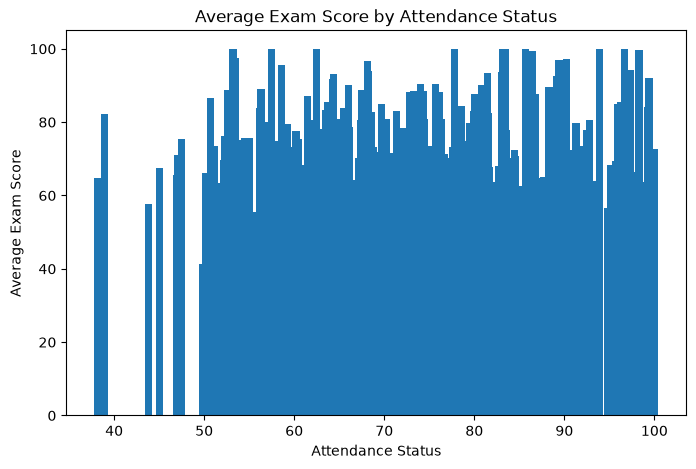

In [101]:
## Questions 3
low_attendance = df[df["attendance_pct"] < 60]

print(low_attendance)
average = df.groupby("class")["attendance_pct"].mean()

print(average)
avg_exam = df.groupby("attendance_pct")["exam_score"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_exam.index, avg_exam.values)

plt.xlabel("Attendance Status")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Attendance Status")

plt.show()

In [106]:
def attendance_status(attendance):
    if attendance >= 80:
        return "Good"
    elif attendance >= 60:
        return "Average"
    else:
        return "Low"

df["attendance_status"] = df["attendance_pct"].apply(attendance_status)
df["attendance_status"]



0         Good
1         Good
2         Good
3      Average
4      Average
        ...   
495    Average
496    Average
497       Good
498       Good
499       Good
Name: attendance_status, Length: 500, dtype: str

75.78537768762678
69.05760000000001
71.39687887323944
risk_level
Low       314
Medium    182
High        4
Name: count, dtype: int64


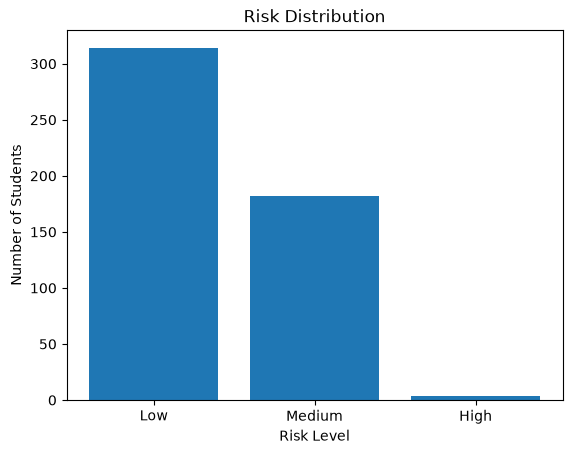

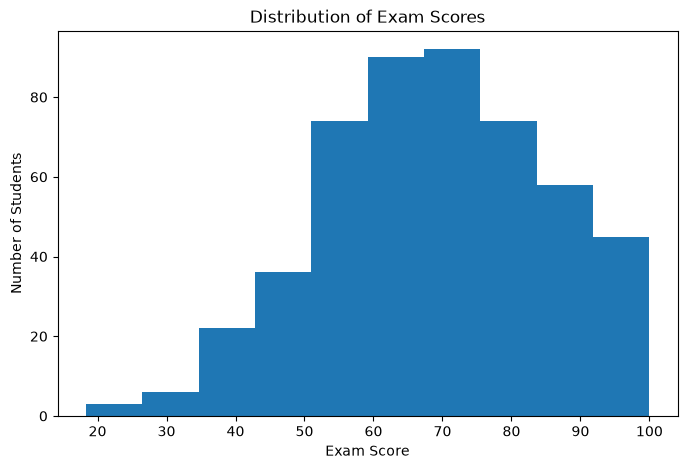

In [124]:
## Questions 4
df.shape[0]
average_attendance =df["attendance_pct"].mean()
print(average_attendance)
exam_score= df["exam_score"].mean()
print(exam_score)
average_course = df["course_completion_pct"].mean()
print(average_course)
risk = df["risk_level"].value_counts()
print(risk)


risk_count = df["risk_level"].value_counts()

plt.bar(risk_count.index, risk_count.values)

plt.title("Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")

plt.show()
#Bargraph
plt.figure(figsize=(8, 5))

plt.hist(df["exam_score"], bins=10)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()